In [2]:
!pip install albumentations -q

In [3]:
!pip install timm -U -q
!pip install urllib3==1.25.4 -q
!pip install boto3 -U -q

In [494]:
import albumentations as A
import albumentations.augmentations.functional as F

import copy
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import pickle
import timm
import torch
import torchvision as tv
import torch.nn as nn
import json
import boto3
from io import BytesIO
from io import StringIO
from urllib.parse import urlparse
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import GroupKFold, KFold
import gc
from sklearn.metrics import (
    accuracy_score, 
    confusion_matrix,
    f1_score, 
    precision_score, 
    recall_score,
    roc_auc_score,
    balanced_accuracy_score,
    average_precision_score
)
from torch.cuda.amp import GradScaler
from torch.cuda.amp import autocast
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import time
import seaborn as sns


In [5]:
client = boto3.client("s3")

def list_all_objects_in_s3(bucketName, prefixName=None):
    """Get a list of objects in an S3 bucket path.
    @params:
    bucketName : s3 bucket 
    prefixName : s3 prefix to bucket
    returns : list of objects in s3 path
    [example of S3 bucket with prefix f"s3://{bucketName}/{prefix}"]
    """
    if prefixName:
        resp = client.list_objects_v2(Bucket=bucketName, StartAfter=prefixName)
    else:
        resp = client.list_objects_v2(Bucket=bucketName)
    list_of_files=[]
    for obj in resp['Contents']:
        files = bucketName+'/'+obj['Key']
        if prefixName:
            if prefixName in files:
                if prefixName!=files:
                    list_of_files.append(files)
        else:
            list_of_files.append(files)
    return list_of_files

def from_s3_npy(s3_uri: str):
    """
    @params 
    data : file content 
    s3_uri : s3 file path along with name [example of S3 bucket with prefix f"s3://{bucketName}/{prefix}/{fileName.npy}"]
    """
    try:
        bytes_ = BytesIO()
        parsed_s3 = urlparse(s3_uri)
        client.download_fileobj(
            Fileobj=bytes_, Bucket=parsed_s3.netloc, Key=parsed_s3.path[1:]
        )
        bytes_.seek(0)
        np_data=np.load(bytes_, allow_pickle=True)
    
    except Exception as e: # work on python 3.x
        print('Failed to read numpy array from S3: '+ str(e))
    return np_data

s3 = boto3.resource("s3")
def read_file_from_s3(bucket, file):
    try:
        obj = s3.Object(bucket, file)
        data = obj.get()["Body"]
        
    except Exception as e: # work on python 3.x
        print("Failed to read file from S3: "+ str(e))
    return data.read().decode(encoding="utf-8")

In [445]:
train = pd.read_csv(StringIO(read_file_from_s3("master-annotation-files", "train_annotations.csv")))
valid = pd.read_csv(StringIO(read_file_from_s3("master-annotation-files", "val_annotations.csv")))
test = pd.read_csv(StringIO(read_file_from_s3("master-annotation-files", "test_annotations.csv")))


In [446]:
train = train[train["sl"] <= 160]
valid = valid[valid["sl"] <= 160]
test = test[test["sl"] <= 160]

In [447]:
train["image"] = train[["scan_id", "sl"]].astype(str).agg("_".join, axis=1)
valid["image"] = valid[["scan_id", "sl"]].astype(str).agg("_".join, axis=1)
test["image"] = test[["scan_id", "sl"]].astype(str).agg("_".join, axis=1)


In [448]:
train

,image_id,category_id,tissue_id,bbox,confidence,labeler,category,supercat_id,supercategory,tissues,file_name,msp_id,msp_file_name,scan_id,subject_id,split,sl,2d_bbox,yolo_bbox,image
0,31,3,1,"[330.0, 232.0, 54.0, 5.0, 19.0, 10.0]",3.0,1,Meniscal Tear (Radial),1,Meniscal Tear,Meniscus,MTR_104.h5,0000025_V00,0000025_V00.h5,MTR_104,25,train,54,"[232.0, 330.0, 19.0, 5.0]","[0.4716796875, 0.6494140625, 0.037109375, 0.00...",MTR_104_54
1,31,3,1,"[330.0, 232.0, 54.0, 5.0, 19.0, 10.0]",3.0,1,Meniscal Tear (Radial),1,Meniscal Tear,Meniscus,MTR_104.h5,0000025_V00,0000025_V00.h5,MTR_104,25,train,55,"[232.0, 330.0, 19.0, 5.0]","[0.4716796875, 0.6494140625, 0.037109375, 0.00...",MTR_104_55
2,31,3,1,"[330.0, 232.0, 54.0, 5.0, 19.0, 10.0]",3.0,1,Meniscal Tear (Radial),1,Meniscal Tear,Meniscus,MTR_104.h5,0000025_V00,0000025_V00.h5,MTR_104,25,train,56,"[232.0, 330.0, 19.0, 5.0]","[0.4716796875, 0.6494140625, 0.037109375, 0.00...",MTR_104_56
3,31,3,1,"[330.0, 232.0, 54.0, 5.0, 19.0, 10.0]",3.0,1,Meniscal Tear (Radial),1,Meniscal Tear,Meniscus,MTR_104.h5,0000025_V00,0000025_V00.h5,MTR_104,25,train,57,"[232.0, 330.0, 19.0, 5.0]","[0.4716796875, 0.6494140625, 0.037109375, 0.00...",MTR_104_57
4,31,3,1,"[330.0, 232.0, 54.0, 5.0, 19.0, 10.0]",3.0,1,Meniscal Tear (Radial),1,Meniscal Tear,Meniscus,MTR_104.h5,0000025_V00,0000025_V00.h5,MTR_104,25,train,58,"[232.0, 330.0, 19.0, 5.0]","[0.4716796875, 0.6494140625, 0.037109375, 0.00...",MTR_104_58
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7834,29,16,-1,"[186.0, 117.0, 49.0, 163.0, 50.0, 58.0]",3.0,2,Effusion,4,Effusion,NaN,MTR_101.h5,0000111_V00,0000111_V00.h5,MTR_101,111,train,102,"[117.0, 186.0, 50.0, 163.0]","[0.27734375, 0.5224609375, 0.09765625, 0.31835...",MTR_101_102
7835,29,16,-1,"[186.0, 117.0, 49.0, 163.0, 50.0, 58.0]",3.0,2,Effusion,4,Effusion,NaN,MTR_101.h5,0000111_V00,0000111_V00.h5,MTR_101,111,train,103,"[117.0, 186.0, 50.0, 163.0]","[0.27734375, 0.5224609375, 0.09765625, 0.31835...",MTR_101_103
7836,29,16,-1,"[186.0, 117.0, 49.0, 163.0, 50.0, 58.0]",3.0,2,Effusion,4,Effusion,NaN,MTR_101.h5,0000111_V00,0000111_V00.h5,MTR_101,111,train,104,"[117.0, 186.0, 50.0, 163.0]","[0.27734375, 0.5224609375, 0.09765625, 0.31835...",MTR_101_104
7837,29,16,-1,"[186.0, 117.0, 49.0, 163.0, 50.0, 58.0]",3.0,2,Effusion,4,Effusion,NaN,MTR_101.h5,0000111_V00,0000111_V00.h5,MTR_101,111,train,105,"[117.0, 186.0, 50.0, 163.0]","[0.27734375, 0.5224609375, 0.09765625, 0.31835...",MTR_101_105


In [449]:
train2 = train
valid2 = valid
test2 = test

In [450]:
train2 = pd.get_dummies(train.supercategory)
valid2 = pd.get_dummies(valid.supercategory)
test2 = pd.get_dummies(test.supercategory)

In [451]:
train = pd.concat([train, train2], axis=1)
valid = pd.concat([valid, valid2], axis=1)
test = pd.concat([test, test2], axis=1)

In [452]:
train_set = train.loc[:, ["image", "Cartilage Lesion", "Effusion", "Ligament Tear", "Meniscal Tear"]]
valid_set = valid.loc[:, ["image", "Cartilage Lesion", "Effusion", "Ligament Tear", "Meniscal Tear"]]
test_set = test.loc[:, ["image", "Cartilage Lesion", "Effusion", "Ligament Tear", "Meniscal Tear"]]

In [453]:
train_cv = pd.concat([train_set, valid_set])

In [454]:
train_cv.shape

(11013, 5)

In [460]:
test_set.shape

(5296, 5)

In [455]:
train_cv = train_cv.drop_duplicates()

In [461]:
test_set = test_set.drop_duplicates()

In [462]:
train_cv.shape

(6160, 5)

In [463]:
test_set.shape

(4731, 5)

In [457]:
train_cv = train_cv.groupby(["image"]).max().reset_index()

In [464]:
test_set = test_set.groupby(["image"]).max().reset_index()

In [458]:
train_cv.shape

(6160, 5)

In [465]:
test_set.shape

(3110, 5)

In [466]:
train_cv_no_eff = train_cv.drop("Effusion", axis=1)

In [467]:
test_set = test_set.drop("Effusion", axis=1)

In [468]:
train_cv_no_eff["Cartilage Lesion and Ligament Tear"] = np.where(((train_cv_no_eff["Cartilage Lesion"]==1) & (train_cv_no_eff["Ligament Tear"]==1) & (train_cv_no_eff["Meniscal Tear"]==0)), 1, 0)
train_cv_no_eff["Cartilage Lesion and Meniscal Tear"] = np.where(((train_cv_no_eff["Cartilage Lesion"]==1) & (train_cv_no_eff["Ligament Tear"]==0) & (train_cv_no_eff["Meniscal Tear"]==1)), 1, 0)
train_cv_no_eff["Meniscal Tear and Ligament Tear"] = np.where(((train_cv_no_eff["Cartilage Lesion"]==0) & (train_cv_no_eff["Ligament Tear"]==1) & (train_cv_no_eff["Meniscal Tear"]==1)), 1, 0)


In [469]:
test_set["Cartilage Lesion and Ligament Tear"] = np.where(((test_set["Cartilage Lesion"]==1) & (test_set["Ligament Tear"]==1) & (test_set["Meniscal Tear"]==0)), 1, 0)
test_set["Cartilage Lesion and Meniscal Tear"] = np.where(((test_set["Cartilage Lesion"]==1) & (test_set["Ligament Tear"]==0) & (test_set["Meniscal Tear"]==1)), 1, 0)
test_set["Meniscal Tear and Ligament Tear"] = np.where(((test_set["Cartilage Lesion"]==0) & (test_set["Ligament Tear"]==1) & (test_set["Meniscal Tear"]==1)), 1, 0)


In [470]:
train_cv_no_eff.loc[train_cv_no_eff["Cartilage Lesion and Ligament Tear"] == 1, "Cartilage Lesion"] = 0
train_cv_no_eff.loc[train_cv_no_eff["Cartilage Lesion and Ligament Tear"] == 1, "Ligament Tear"] = 0

train_cv_no_eff.loc[train_cv_no_eff["Cartilage Lesion and Meniscal Tear"] == 1, "Cartilage Lesion"] = 0
train_cv_no_eff.loc[train_cv_no_eff["Cartilage Lesion and Meniscal Tear"] == 1, "Meniscal Tear"] = 0

train_cv_no_eff.loc[train_cv_no_eff["Meniscal Tear and Ligament Tear"] == 1, "Meniscal Tear"] = 0
train_cv_no_eff.loc[train_cv_no_eff["Meniscal Tear and Ligament Tear"] == 1, "Ligament Tear"] = 0

In [471]:
test_set.loc[test_set["Cartilage Lesion and Ligament Tear"] == 1, "Cartilage Lesion"] = 0
test_set.loc[test_set["Cartilage Lesion and Ligament Tear"] == 1, "Ligament Tear"] = 0

test_set.loc[test_set["Cartilage Lesion and Meniscal Tear"] == 1, "Cartilage Lesion"] = 0
test_set.loc[test_set["Cartilage Lesion and Meniscal Tear"] == 1, "Meniscal Tear"] = 0

test_set.loc[test_set["Meniscal Tear and Ligament Tear"] == 1, "Meniscal Tear"] = 0
test_set.loc[test_set["Meniscal Tear and Ligament Tear"] == 1, "Ligament Tear"] = 0

In [472]:
train_cv_no_eff["None of Above"] = np.where(((train_cv_no_eff["Cartilage Lesion"]==0) & (train_cv_no_eff["Ligament Tear"]==0) & (train_cv_no_eff["Meniscal Tear"]==0) & (train_cv_no_eff["Cartilage Lesion and Ligament Tear"]==0) & (train_cv_no_eff["Cartilage Lesion and Meniscal Tear"]==0) & (train_cv_no_eff["Meniscal Tear and Ligament Tear"]==0)), 1, 0)


In [473]:
test_set["None of Above"] = np.where(((test_set["Cartilage Lesion"]==0) & (test_set["Ligament Tear"]==0) & (test_set["Meniscal Tear"]==0) & (test_set["Cartilage Lesion and Ligament Tear"]==0) & (test_set["Cartilage Lesion and Meniscal Tear"]==0) & (test_set["Meniscal Tear and Ligament Tear"]==0)), 1, 0)



In [474]:
train_cv_no_eff["Cartilage Lesion"] = train_cv_no_eff["Cartilage Lesion"].astype("float")
train_cv_no_eff["Ligament Tear"] = train_cv_no_eff["Ligament Tear"].astype("float")
train_cv_no_eff["Meniscal Tear"] = train_cv_no_eff["Meniscal Tear"].astype("float")
train_cv_no_eff["None of Above"] = train_cv_no_eff["None of Above"].astype("float")
train_cv_no_eff["Cartilage Lesion and Ligament Tear"] = train_cv_no_eff["Cartilage Lesion and Ligament Tear"].astype("float")
train_cv_no_eff["Cartilage Lesion and Meniscal Tear"] = train_cv_no_eff["Cartilage Lesion and Meniscal Tear"].astype("float")
train_cv_no_eff["Meniscal Tear and Ligament Tear"] = train_cv_no_eff["Meniscal Tear and Ligament Tear"].astype("float")


In [475]:
train_cv_no_eff.sum(axis=0)

image                                 MTR_001_77MTR_001_78MTR_001_79MTR_001_80MTR_00...
Cartilage Lesion                                                                 2056.0
Ligament Tear                                                                     266.0
Meniscal Tear                                                                     639.0
Cartilage Lesion and Ligament Tear                                                226.0
Cartilage Lesion and Meniscal Tear                                                771.0
Meniscal Tear and Ligament Tear                                                    26.0
None of Above                                                                    2208.0
dtype: object

In [476]:
test_set["Cartilage Lesion"] = test_set["Cartilage Lesion"].astype("float")
test_set["Ligament Tear"] = test_set["Ligament Tear"].astype("float")
test_set["Meniscal Tear"] = test_set["Meniscal Tear"].astype("float")
test_set["None of Above"] = test_set["None of Above"].astype("float")
test_set["Cartilage Lesion and Ligament Tear"] = test_set["Cartilage Lesion and Ligament Tear"].astype("float")
test_set["Cartilage Lesion and Meniscal Tear"] = test_set["Cartilage Lesion and Meniscal Tear"].astype("float")
test_set["Meniscal Tear and Ligament Tear"] = test_set["Meniscal Tear and Ligament Tear"].astype("float")


In [477]:
test_set.sum(axis=0)

image                                 MTR_005_100MTR_005_101MTR_005_102MTR_005_103MT...
Cartilage Lesion                                                                  759.0
Ligament Tear                                                                     165.0
Meniscal Tear                                                                     305.0
Cartilage Lesion and Ligament Tear                                                123.0
Cartilage Lesion and Meniscal Tear                                                333.0
Meniscal Tear and Ligament Tear                                                     0.0
None of Above                                                                    1427.0
dtype: object

In [326]:
# sample the dataset so that each class is more balanced
train_cv_no_eff = train_cv_no_eff.drop(train_cv_no_eff[(train_cv_no_eff["Cartilage Lesion"] == 1)].sample(frac = .8).index)
train_cv_no_eff = train_cv_no_eff.drop(train_cv_no_eff[(train_cv_no_eff["None of Above"] == 1)].sample(frac = .8).index)



In [394]:
train_cv_no_eff.sum(axis=0)

image                                 MTR_001_77MTR_001_78MTR_001_79MTR_001_80MTR_00...
Cartilage Lesion                                                                  411.0
Ligament Tear                                                                     252.0
Meniscal Tear                                                                     625.0
Cartilage Lesion and Ligament Tear                                                226.0
Cartilage Lesion and Meniscal Tear                                                771.0
Meniscal Tear and Ligament Tear                                                    26.0
None of Above                                                                     442.0
split                                                                            2748.0
dtype: object

In [328]:
train_cv_no_eff = train_cv_no_eff.reset_index()
train_cv_no_eff = train_cv_no_eff.drop("index", axis = 1)

In [329]:
train_cv_no_eff

,image,Cartilage Lesion,Ligament Tear,Meniscal Tear,Cartilage Lesion and Ligament Tear,Cartilage Lesion and Meniscal Tear,Meniscal Tear and Ligament Tear,None of Above
0,MTR_001_77,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,MTR_001_78,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,MTR_001_79,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,MTR_001_80,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,MTR_001_81,0.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...
2744,MTR_251_87,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2745,MTR_251_90,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2746,MTR_251_91,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2747,MTR_251_96,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
timm.list_models()

In [480]:
# Global variables
N_FOLDS = 3
MAX_LR = 2.0e-4
SAVE_CHECKPOINT_EVERY_STEP = 2000
CHECKPOINT_PATH = "/home/ec2-user/SageMaker/models"
PREDICT_MAX_BATCHES = 1e9
MAX_TRAIN_BATCHES = 10000
EPOCHS = 10
BACKBONE = "efficientnet_b1"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if DEVICE == "cuda":
    BATCH_SIZE = 8
else:
    BATCH_SIZE = 2

In [481]:
# CV splits
split = GroupKFold(N_FOLDS)

for k, (_, test_idx) in enumerate(split.split(train_cv_no_eff, groups=train_cv_no_eff.image)):
    train_cv_no_eff.loc[test_idx, "split"] = k

In [332]:
train_cv_no_eff.sample(5)

,image,Cartilage Lesion,Ligament Tear,Meniscal Tear,Cartilage Lesion and Ligament Tear,Cartilage Lesion and Meniscal Tear,Meniscal Tear and Ligament Tear,None of Above,split
2443,MTR_222_90,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
961,MTR_105_42,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2528,MTR_230_59,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
1312,MTR_140_67,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2194,MTR_203_106,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [482]:
class LesionDataset(torch.utils.data.Dataset):
    def __init__(self, df, transform=None):
        super().__init__()
        self.df = df
        self.transform = transform
        self.classes = ["Cartilage Lesion", "Ligament Tear", "Meniscal Tear", "Cartilage Lesion and Ligament Tear", "Cartilage Lesion and Meniscal Tear", "Meniscal Tear and Ligament Tear", "None of Above"]
        
    def __getitem__(self, i):
        row = self.df.iloc[i]
        image_id = row.image
        img = from_s3_npy("s3://skm-dataset-echo1/" + image_id + ".npy")

        # Apply image transformations (if any)
        if self.transform is not None:
            x = self.transform(image=img)["image"]
        else:
            x = img

        # Labels
        y = torch.tensor(np.array([float(row[c]) for c in self.classes]), dtype=torch.float32)

        return x, y

    def __len__(self):
        return len(self.df)

In [483]:
# Image augmentations
train_transform = A.Compose([
    A.GaussianBlur((3, 7), p=0.25),
    A.RandomRotate90(p=0.25),
    A.OneOf([
        A.MotionBlur(p=0.2),
        A.Blur(blur_limit=3, p=0.1),
    ], p=0.5),
    A.ShiftScaleRotate(shift_limit=0.0625, scale_limit=0.2, rotate_limit=45, interpolation=cv2.INTER_LINEAR, border_mode=cv2.BORDER_CONSTANT, p=0.25),
    A.OneOf([
        A.OpticalDistortion(p=0.3),
        A.GridDistortion(p=0.1),
    ], p=0.25),
    ToTensorV2(p=1.0)
])

valid_transform = A.Compose([
    ToTensorV2(p=1.0)
])
     

In [484]:
# Check the dataset outputs
dataset_train = LesionDataset(train_cv_no_eff, train_transform)
x, y = dataset_train[500]
print(x.shape, y.shape)

torch.Size([1, 512, 512]) torch.Size([7])


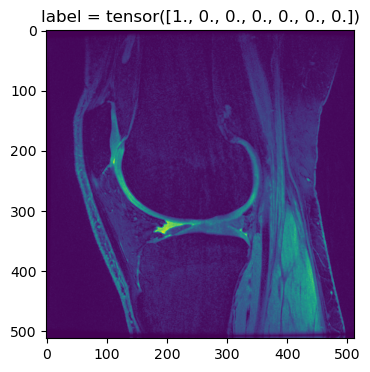

In [485]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(4, 4))
ax.imshow(np.transpose(x, (1, 2, 0)))
ax.set_title(f"label = {y}")
plt.show()

In [486]:
# Custom model class
class LesionModel(nn.Module):
    def __init__(self, backbone):
        super().__init__()
        self.model = timm.create_model(backbone, pretrained=True, in_chans=1, num_classes=7)

    def forward(self, x):
        x = self.model(x)
        return x

In [487]:
# Quick test of the model
print(BACKBONE)
model = LesionModel(BACKBONE)
print(model(torch.randn(1, 1, 512, 512)))
del model

efficientnet_b1
tensor([[-1.5703,  1.7090,  1.2955, -1.0571,  0.6051,  1.3434,  2.0181]],
       grad_fn=<AddmmBackward0>)


In [488]:
def gc_collect():
    """Performs garbage removal after memory-intensive operations."""
    gc.collect()
    torch.cuda.empty_cache()
    
def load_model(model, path, device="cpu"):
    """Loads a model from a specified location.

    Args:
        model: An instance of the model class to load.
        path: A path to load model weights from.
        device: A device to place the model onto.

    Returns:
        model: The model with the loaded weights.
    """
    weights = torch.load(os.path.join(path), map_location=device)
    model.load_state_dict(weights)
    return model

def save_model(model, path):
    """Saves a model.

    Args:
        model: The model to save.
        path: The path to the saved model file.
    """
    torch.save(model.state_dict(), path)
    
def save_cm(df, path):
    df.to_csv(path, index=False)

In [495]:
def get_top_k_metrics(y_true, y_pred, k):
    """Retrieves the top-n predictions.

    Args:
        y_true: An array of the true sample labels.
        y_pred: An array of the predicted sample probabilities.
        k: The number of top class probabilities to consider.
    Returns:
        metrics: A dict of top-k metrics (accuracy, precision, recall, f1, confusion matrix)
    """
    y_true_labels = np.argmax(y_true, axis=1)
    sorted_pred = np.argsort(y_pred, axis=1, kind="mergesort")[:, ::-1][:, :k]
    hits = (y_true_labels == sorted_pred.T).any(axis=0).astype(np.uint8)
    #accuracy = hits.mean()
    balanced_accuracy = balanced_accuracy_score(y_true_labels, sorted_pred)
    tp = np.array([hits[y_true_labels == i].sum() for i in range(7)])
    fn = np.array([((y_true_labels == i) & np.logical_not((sorted_pred == i).any(axis=1))).sum() for i in range(7)])
    fp = np.array([((y_true_labels != i) & (hits == 0) & (sorted_pred == i).any(axis=1)).sum() for i in range(7)])
    precision = tp / (tp + fp)
    recall = tp / (tp + fn)
    f2 = (1 + 2.0 ** 2) * precision * recall / (2.0 ** 2 * precision + recall)
    cm = np.array([[((y_true_labels == i) & (sorted_pred == j).any(axis=1)).sum() for j in range(7)] for i in range(7)])
    metrics = {
        "balanced_accuracy": balanced_accuracy,
        "precision": precision,
        "recall": recall,
        "f2": f2,
        "confusion_matrix": cm
    }
    return metrics

In [215]:
def get_metrics(y_true, y_pred, threshold=0.5):
    y_pred = np.array(y_pred > threshold, dtype=float)
    print(y_true, y_pred)
    metrics =  {
        'micro/precision': precision_score(y_true=y_true, y_pred=y_pred, average='micro'),
        'micro/recall': recall_score(y_true=y_true, y_pred=y_pred, average='micro'),
        'micro/f1': f1_score(y_true=y_true, y_pred=y_pred, average='micro'),
        'macro/precision': precision_score(y_true=y_true, y_pred=y_pred, average='macro'),
        'macro/recall': recall_score(y_true=y_true, y_pred=y_pred, average='macro'),
        'macro/f1': f1_score(y_true=y_true, y_pred=y_pred, average='macro'),
        'confusion matrix': confusion_matrix(y_true=y_true, y_pred=y_pred)
    }
    return metrics

In [496]:
def evaluate_classification_model(
    model, 
    dataset, 
    max_batches, 
    device="cpu", 
    batch_size=2,
    shuffle=False
):
    """Evaluates a lesion classification model against a dataset.

    Args:
        model: A model to be evaluated.
        dataset: A dataset object containing images to evaluate the model with.
        max_batches: The number of batches to run the evaluation loop for. If the number of
            iterations exceeds max_batches, the loop will terminate.
        device: A device to run the evaluation loop on.
        batch_size: The number of images to process at the same time.
        shuffle: A boolean signifying whether or not to shuffle the dataset.

    Returns:
        loss: The average cross-entropy loss across all images in the dataset.
        roc_auc: The average ROC AUC score across all classes and images in the dataset.
        f1: The average F1 score across all classes and images in the dataset.
    """
    torch.manual_seed(42)
    model = model.to(device)
    model.eval()
    loader_test = torch.utils.data.DataLoader(
        dataset, 
        batch_size=batch_size, 
        shuffle=shuffle, 
        num_workers=os.cpu_count()
    )
    y_true = []
    y_pred = []
    total_loss = 0.0
    n = 0
    with torch.no_grad():
        with tqdm(loader_test) as loader_:
            for i, (x, y) in enumerate(loader_):
                x = x.to(device, dtype=torch.float)
                y = y.to(device)
                logits = model(x)
                #loss = nn.CrossEntropyLoss()(logits, y.float())
                loss = nn.BCEWithLogitsLoss()(logits, y.float())
                y_pred.append(torch.nn.functional.softmax(logits, dim=-1).cpu().numpy())
                y_true.append(y.cpu().numpy())
                total_loss += loss.item() * x.size(0)
                n += x.size(0)
                loader_.set_description(f"loss = {total_loss / n:.04f}")
                if i >= max_batches:
                    break
    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    loss = total_loss / n
    roc_auc = roc_auc_score(y_true, y_pred, multi_class="ovr", average="macro")
    print("\n\n[EVALUATION METRICS]")
    print(f"Loss: {loss:.04f}")
    print(f"ROC AUC: {roc_auc:.04f}\n")
    for k in range(1, 2):
        metrics = get_top_k_metrics(y_true, y_pred, k)
        print(f"F2: {metrics['f2'].mean():.04f}")
        print(f"Precision: {metrics['precision'].mean():.04f}")
        print(f"Recall: {metrics['recall'].mean():.04f}")
        print(f"Balanced Accuracy: {metrics['balanced_accuracy'].mean():.04f}")
        if k == 1:
            cm = pd.DataFrame(metrics["confusion_matrix"], index=dataset.classes, columns=dataset.classes)
            print(f"Confusion Matrix:\n{cm}")
        print()
    return loss, cm

def train_classification_model(
    model,
    dataset_train,
    dataset_valid,
    path,
    path_cm,
    class_weights=None,
    batch_size=8,
    device="cpu",
    epochs=1,
    max_lr=2.0e-4
):
    """Trains a classification model.

    Args:
        model: The model to train.
        dataset_train: A training dataset.
        dataset_valid: A validation dataset.
        path: A path to save the model to.
        class_weights: The relative weight of each lesion class when computing the cross-entropy loss.
        batch_size: The number of images to process at the same time.
        device: A device to run the training loop on.

    Returns:
        model: The best model from the training loop.
    """
    torch.manual_seed(42)
    loader_train = torch.utils.data.DataLoader(
        dataset_train, 
        batch_size=batch_size, 
        shuffle=True, 
        num_workers=os.cpu_count(),
        pin_memory=True,
        timeout=120
    )
    optim = torch.optim.RAdam(model.parameters())
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optim, 
        max_lr=max_lr, 
        epochs=epochs,
        steps_per_epoch=len(loader_train),
        pct_start=0.3
    )
    model.train()
    if class_weights is not None:
        class_weights = torch.tensor(class_weights).to(device)
    scaler = GradScaler()
    best_loss = float("inf")
    best_cm = pd.DataFrame()
    best_model = copy.deepcopy(model)
    for epoch in range(epochs):
        print(f"[EPOCH {epoch + 1}/{epochs}]")
        with tqdm(loader_train) as loader_:
            total_loss = 0.0
            n = 0
            for i, (x, y) in enumerate(loader_):
                optim.zero_grad()
                with autocast():
                    x = x.to(device, dtype=torch.float)
                    y = y.to(device)
                    logits = model(x)
                    loss = nn.BCEWithLogitsLoss(weight=class_weights)(logits, y.float())
                    if np.isinf(loss.item()) or np.isnan(loss.item()):
                        print(f"Bad loss, skipping batch {i}")
                        del loss
                        gc_collect()
                        continue
                scaler.scale(loss).backward()
                scaler.step(optim)
                scaler.update()
                scheduler.step()
                total_loss += loss.item() * x.size(0)
                n += x.size(0)
                loader_.set_description(f"loss = {total_loss / n :.04f}")
        loss, cm = evaluate_classification_model(
            model, 
            dataset_valid, 
            max_batches=10000, 
            device=device, 
            batch_size=batch_size,
            shuffle=False
        )
        if loss < best_loss: 
            save_model(model, path)
            best_loss = loss
            best_model = copy.deepcopy(model)
            save_cm(cm, path_cm)
    return best_model

def predict_lesion(x, y, model, device, verbose=True):
    """Predicts the lesion class for a given image.

    Args:
        x: An image to predict lesions for.
        y: The true label for the image.
        model: A model to use to make predictions.
        device: A device to evaluate on.
        verbose: A boolean flag indicating whether or not to display additional information.
    """
    x = x.to(device, dtype=torch.float)[None, :]
    y = y.to(device)[None, :]
    model = model.to(device)
    model.eval()
    with torch.no_grad():
        logits = model(x)
        loss = nn.BCEWithLogitsLoss()(logits, y.float())
        y_pred = torch.nn.functional.softmax(logits, dim=-1)[0]
        loss += loss.item()
    if verbose:
        fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(4, 4))
        ax.imshow(np.transpose(x[0].cpu().numpy(), (1, 2, 0)))
        print(f"y_true = {y.cpu().numpy()[0]}")
        print(f"y_pred = {np.around(y_pred.cpu().numpy(), 3)}")


def visualize_features(x, y, model, device, k=1):
    """Visualizes the learned kernel features of a CNN model.

    Args:
        x: An image to predict lesions for.
        y: The true label for the image.
        model: A model to use to make predictions.
        device: A device to evaluate on.
    """
    x = x.to(device, dtype=torch.float)[None, :]
    y = y.to(device)[None, :]
    model = model.to(device)
    model.eval()
    with torch.no_grad():
        layers = list(model.model.children())
        f = x
        for i in range(k):
            layer = layers[i]
            f = layer(f)
    fig, axs = plt.subplots(nrows=8, ncols=4, figsize=(4 * 4, 8 * 4))
    for i in range(8):
        for j in range(4):
            ax = axs[i, j]
            ax.imshow(f[0, i + j].cpu().numpy())
            ax.set_title(i + j)

In [497]:
# Training loop
t0 = time.time()
classification_models = []
for fold in range(N_FOLDS):
    print(f"[FOLD {fold + 1}/{N_FOLDS}]")
    path = os.path.join(CHECKPOINT_PATH, f"efficientnetb1-f{fold}.tph")
    path_cm = os.path.join(CHECKPOINT_PATH, f"cm_efficientnetb1-f{fold}.csv")
    # Load the models if they already exist
    if os.path.exists(path):
        print(f"Found cached version of {path}")
        classification_models.append(load_model(LesionModel(BACKBONE), path, DEVICE))
    else:
        gc_collect()
        dataset_train = LesionDataset(train_cv_no_eff.query("split != @fold"), train_transform)
        dataset_valid = LesionDataset(train_cv_no_eff.query("split == @fold"), valid_transform)
        model = LesionModel(BACKBONE).to(DEVICE)
        classification_models.append(
            train_classification_model(
                model,
                dataset_train,
                dataset_valid,
                path,
                path_cm,
                class_weights=None,
                batch_size=BATCH_SIZE,
                device=DEVICE,
                epochs=EPOCHS,
                max_lr=MAX_LR
            )
        )
        
print(f"total training time: {time.time() - t0}")

[FOLD 1/3]
[EPOCH 1/10]


  0%|          | 0/514 [00:00<?, ?it/s]/home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:139: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn("Detected call of `lr_scheduler.step()` before `optimizer.step()`. "
loss = 0.3510: 100%|██████████| 257/257 [00:26<00:00,  9.56it/s]
/tmp/ipykernel_7353/2748713017.py:21: RuntimeWarning: invalid value encountered in divide
  f2 = (1 + 2.0 ** 2) * precision * recall / (2.0 ** 2 * precision + recall)




[EVALUATION METRICS]
Loss: 0.3510
ROC AUC: 0.6246

F2: nan
Precision: 0.2550
Recall: 0.2054
Balanced Accuracy: 0.2054
Confusion Matrix:
                                    Cartilage Lesion  Ligament Tear  \
Cartilage Lesion                                 406             20   
Ligament Tear                                     38              2   
Meniscal Tear                                     79              1   
Cartilage Lesion and Ligament Tear                53              3   
Cartilage Lesion and Meniscal Tear               116              6   
Meniscal Tear and Ligament Tear                    4              0   
None of Above                                    266             11   

                                    Meniscal Tear  \
Cartilage Lesion                               19   
Ligament Tear                                   8   
Meniscal Tear                                  30   
Cartilage Lesion and Ligament Tear              0   
Cartilage Lesion and Menisca

loss = 0.2709: 100%|██████████| 257/257 [00:26<00:00,  9.67it/s]
/tmp/ipykernel_7353/2748713017.py:19: RuntimeWarning: invalid value encountered in divide
  precision = tp / (tp + fp)




[EVALUATION METRICS]
Loss: 0.2709
ROC AUC: 0.8846

F2: nan
Precision: nan
Recall: 0.2871
Balanced Accuracy: 0.2871
Confusion Matrix:
                                    Cartilage Lesion  Ligament Tear  \
Cartilage Lesion                                 614              0   
Ligament Tear                                     50             10   
Meniscal Tear                                     92              0   
Cartilage Lesion and Ligament Tear                65              0   
Cartilage Lesion and Meniscal Tear               181              0   
Meniscal Tear and Ligament Tear                    8              0   
None of Above                                    324              2   

                                    Meniscal Tear  \
Cartilage Lesion                               15   
Ligament Tear                                   1   
Meniscal Tear                                  79   
Cartilage Lesion and Ligament Tear              0   
Cartilage Lesion and Meniscal T

...



[EVALUATION METRICS]
Loss: 0.0984
ROC AUC: 0.9920

F2: 0.9072
Precision: 0.9237
Recall: 0.9038
Balanced Accuracy: 0.9038
Confusion Matrix:
                                    Cartilage Lesion  Ligament Tear  \
Cartilage Lesion                                 643              1   
Ligament Tear                                      4             65   
Meniscal Tear                                      2              0   
Cartilage Lesion and Ligament Tear                 2              3   
Cartilage Lesion and Meniscal Tear                17              0   
Meniscal Tear and Ligament Tear                    0              1   
None of Above                                     27              4   

                                    Meniscal Tear  \
Cartilage Lesion                                2   
Ligament Tear                                   0   
Meniscal Tear                                 190   
Cartilage Lesion and Ligament Tear              0   
Cartilage Lesion and Meni

loss = 0.1033: 100%|██████████| 257/257 [00:24<00:00, 10.62it/s]




[EVALUATION METRICS]
Loss: 0.1033
ROC AUC: 0.9924

F2: 0.8924
Precision: 0.9239
Recall: 0.8861
Balanced Accuracy: 0.8861
Confusion Matrix:
                                    Cartilage Lesion  Ligament Tear  \
Cartilage Lesion                                 642              2   
Ligament Tear                                      4             65   
Meniscal Tear                                      1              0   
Cartilage Lesion and Ligament Tear                 3              4   
Cartilage Lesion and Meniscal Tear                16              0   
Meniscal Tear and Ligament Tear                    0              2   
None of Above                                     25              4   

                                    Meniscal Tear  \
Cartilage Lesion                                2   
Ligament Tear                                   0   
Meniscal Tear                                 189   
Cartilage Lesion and Ligament Tear              0   
Cartilage Lesion and Meni

loss = 0.1041: 100%|██████████| 257/257 [00:23<00:00, 10.83it/s]



[EVALUATION METRICS]
Loss: 0.1041
ROC AUC: 0.9924

F2: 0.8942
Precision: 0.9257
Recall: 0.8879
Balanced Accuracy: 0.8879
Confusion Matrix:
                                    Cartilage Lesion  Ligament Tear  \
Cartilage Lesion                                 642              2   
Ligament Tear                                      4             65   
Meniscal Tear                                      1              0   
Cartilage Lesion and Ligament Tear                 3              3   
Cartilage Lesion and Meniscal Tear                16              0   
Meniscal Tear and Ligament Tear                    0              2   
None of Above                                     25              4   

                                    Meniscal Tear  \
Cartilage Lesion                                2   
Ligament Tear                                   0   
Meniscal Tear                                 189   
Cartilage Lesion and Ligament Tear              0   
Cartilage Lesion and Meni

In [498]:
cm = pd.read_csv("models/cm_efficientnetb1-f2.csv")
cm = cm.rename(index = {0:"Cartilage Lesion", 1:"Ligament Tear", 2:"Meniscal Tear", 3:"Not Cartilage Lesion", 4:"Cartilage Lesion and Ligament Tear", 5:"Cartilage Lesion and Meniscal Tear", 6:"Meniscal Tear and Ligament Tear", 7:"None of Above"})
cm

,Cartilage Lesion,Ligament Tear,Meniscal Tear,Cartilage Lesion and Ligament Tear,Cartilage Lesion and Meniscal Tear,Meniscal Tear and Ligament Tear,None of Above
Cartilage Lesion,643,1,2,5,7,0,30
Ligament Tear,4,65,0,4,0,0,5
Meniscal Tear,2,0,190,0,7,0,10
Not Cartilage Lesion,2,3,0,75,0,0,0
Cartilage Lesion and Ligament Tear,17,0,10,2,221,0,3
Cartilage Lesion and Meniscal Tear,0,1,0,0,0,8,0
Meniscal Tear and Ligament Tear,27,4,5,0,1,0,699


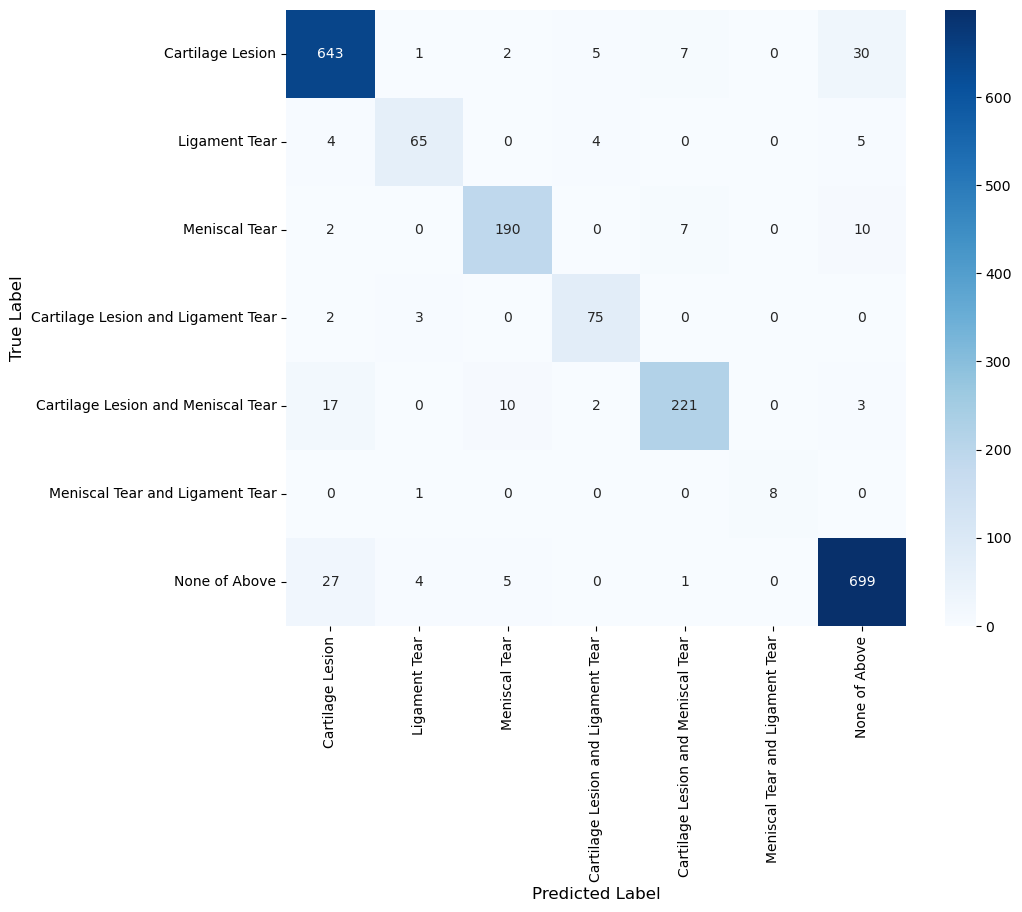

In [499]:
plt.figure(figsize = (10, 8))
p = sns.heatmap(cm, cmap="Blues", annot=True, fmt="g")
p.set_yticklabels(labels = ["Cartilage Lesion", "Ligament Tear", "Meniscal Tear", "Cartilage Lesion and Ligament Tear", "Cartilage Lesion and Meniscal Tear", "Meniscal Tear and Ligament Tear", "None of Above"], rotation=0)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.show()

In [500]:
test_set

,image,Cartilage Lesion,Ligament Tear,Meniscal Tear,Cartilage Lesion and Ligament Tear,Cartilage Lesion and Meniscal Tear,Meniscal Tear and Ligament Tear,None of Above
0,MTR_005_100,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,MTR_005_101,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,MTR_005_102,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,MTR_005_103,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,MTR_005_104,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...
3105,MTR_248_95,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3106,MTR_248_96,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3107,MTR_248_97,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3108,MTR_248_98,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [510]:
test_set.sum(axis=0)

image                                 MTR_005_100MTR_005_101MTR_005_102MTR_005_103MT...
Cartilage Lesion                                                                  759.0
Ligament Tear                                                                     165.0
Meniscal Tear                                                                     305.0
Cartilage Lesion and Ligament Tear                                                123.0
Cartilage Lesion and Meniscal Tear                                                333.0
Meniscal Tear and Ligament Tear                                                     0.0
None of Above                                                                    1427.0
dtype: object

In [501]:
dataset_test = LesionDataset(test_set, valid_transform)


In [502]:
model = load_model(LesionModel(BACKBONE), "models/efficientnetb1-f2.tph").to(DEVICE)

In [416]:
i = np.argwhere(test_set["Cartilage Lesion"].values == 1.0)[20][0]
x, y = dataset_test[i]

y_true = [1. 0. 0. 0. 0. 0. 0.]
y_pred = [0.996 0.004 0.    0.    0.    0.    0.   ]


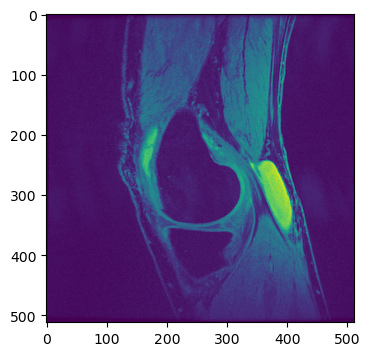

In [417]:
predict_lesion(x, y, model, DEVICE)


In [503]:
def predict_lesion_test(x, y, model, device):
    """Predicts the lesion class for a given image.

    Args:
        x: An image to predict lesions for.
        y: The true label for the image.
        model: A model to use to make predictions.
        device: A device to evaluate on.
    """

    x = x.to(device, dtype=torch.float)[None, :]
    y = y.to(device)[None, :]
    model = model.to(device)
    model.eval()
    with torch.no_grad():
        logits = model(x)
        y_pred = torch.nn.functional.softmax(logits, dim=-1).cpu().numpy()
        y_true = y.cpu().numpy()
        
    return y_true, y_pred

In [516]:
model = load_model(LesionModel(BACKBONE), "models/efficientnetb1-f2.tph").to(DEVICE)
dataset_test = LesionDataset(test_set, valid_transform)

y_true_list = []
y_pred_list = []

for i in range(len(dataset_test)):
    x, y = dataset_test[i]
    y_true, y_pred = predict_lesion_test(x, y, model, DEVICE)
    y_pred_list.append(y_pred)
    y_true_list.append(y_true)

y_true_list = np.concatenate(y_true_list)
y_pred_list = np.concatenate(y_pred_list)



In [517]:
classes = ["Cartilage Lesion", "Ligament Tear", "Meniscal Tear", "Cartilage Lesion and Ligament Tear", "Cartilage Lesion and Meniscal Tear", "Meniscal Tear and Ligament Tear", "None of Above"]

In [518]:
metrics = get_top_k_metrics(y_true_list, y_pred_list, 1)

print(f"F2: {metrics['f2'].mean():.04f}")
print(f"Precision: {metrics['precision'].mean():.04f}")
print(f"Recall: {metrics['recall'].mean():.04f}")
print(f"Balanced Accuracy: {metrics['balanced_accuracy'].mean():.04f}")
cm = pd.DataFrame(metrics["confusion_matrix"], index=classes, columns=classes)
save_cm(cm, "models/test_cm.csv")


F2: nan
Precision: nan
Recall: nan
Balanced Accuracy: 0.2927


/tmp/ipykernel_7353/2748713017.py:19: RuntimeWarning: invalid value encountered in divide
  precision = tp / (tp + fp)
/tmp/ipykernel_7353/2748713017.py:20: RuntimeWarning: invalid value encountered in divide
  recall = tp / (tp + fn)


In [519]:
test_cm = pd.read_csv("models/test_cm.csv")
test_cm = test_cm.rename(index = {0:"Cartilage Lesion", 1:"Ligament Tear", 2:"Meniscal Tear", 3:"Not Cartilage Lesion", 4:"Cartilage Lesion and Ligament Tear", 5:"Cartilage Lesion and Meniscal Tear", 6:"Meniscal Tear and Ligament Tear", 7:"None of Above"})


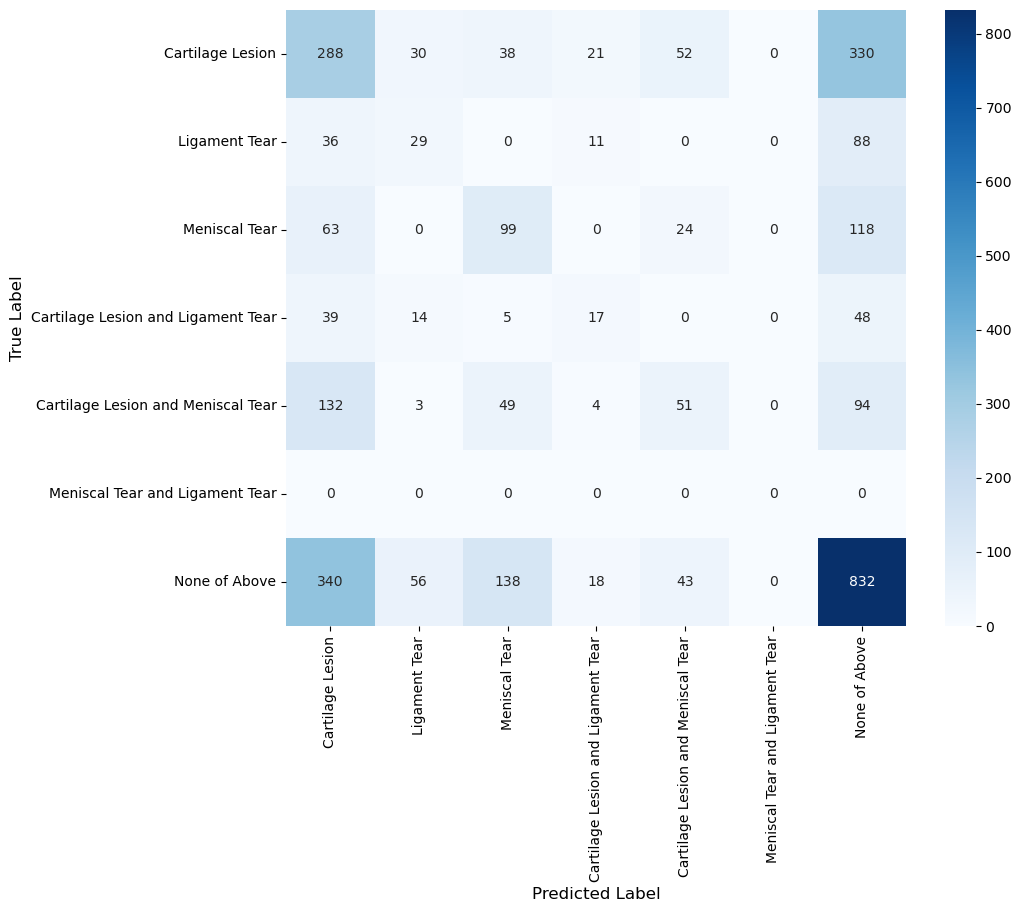

In [520]:
plt.figure(figsize = (10, 8))
p = sns.heatmap(test_cm, cmap="Blues", annot=True, fmt="g")
p.set_yticklabels(labels = ["Cartilage Lesion", "Ligament Tear", "Meniscal Tear", "Cartilage Lesion and Ligament Tear", "Cartilage Lesion and Meniscal Tear", "Meniscal Tear and Ligament Tear", "None of Above"], rotation=0)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.show()